# CNN and Bottleneck from Scratch

---

1. **Implement** a 2D Convolution layer from scratch
2. **Implement** Cross-Entropy loss from scratch
3. **Build** a standard CNN architecture
4. **Build** a Bottleneck CNN with 1×1 convolutions
5. **Compare** parameter counts between architectures
6. **Train** both models on CIFAR-10
7. **Visualize** predictions and confusion matrices

**Dataset**: CIFAR-10 (60,000 color 32×32 images, 10 classes)


## Part 0: Environment Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.auto import tqdm
import time

# Set seeds for reproducibility (DO NOT MODIFY)
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Configuration (DO NOT MODIFY)
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

BATCH_SIZE = 128
LEARNING_RATE = 1e-3
NUM_EPOCHS = 15
NUM_CLASSES = 10

## Part 1: Data Loading

In [3]:
# Data loading (provided)
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")

100%|██████████| 170M/170M [00:12<00:00, 13.5MB/s] 


Training samples: 50000
Test samples: 10000
Image shape: torch.Size([3, 32, 32])


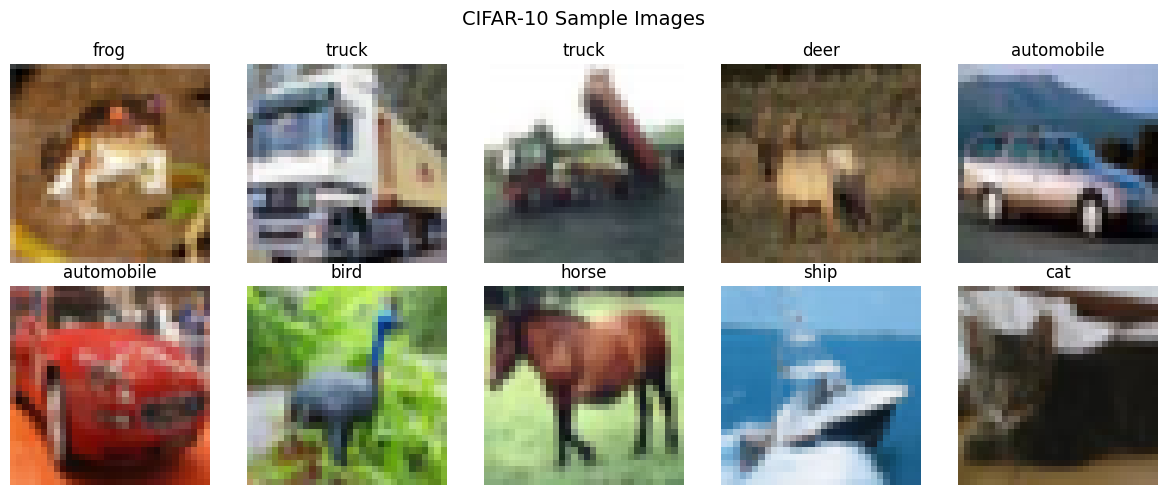

In [4]:
# Visualize sample images (provided)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# Use unnormalized data for visualization
viz_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())

for i, ax in enumerate(axes.flat):
    img, label = viz_dataset[i]
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(CLASS_NAMES[label])
    ax.axis('off')
plt.suptitle('CIFAR-10 Sample Images', fontsize=14)
plt.tight_layout()
plt.show()

## Part 2: Implementing Conv2D from Scratch 

Implement a 2D convolutional layer using only *NumPy* operations. This will help me understand the mechanics of convolution.

**Key Concepts:**
- Input shape: (batch_size, in_channels, height, width)
- Kernel shape: (out_channels, in_channels, kernel_height, kernel_width)
- Output shape depends on padding and stride

In [5]:
class Conv2DFromScratch:
    """
    A 2D Convolutional layer implemented from scratch.

    Args:
        in_channels: Number of input channels
        out_channels: Number of output channels (number of filters)
        kernel_size: Size of the convolutional kernel
        stride: Stride of the convolution
        padding: Zero-padding added to both sides of the input
    """

    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

        # Initialize weights using Kaiming initialization
        scale = np.sqrt(2.0 / (in_channels * kernel_size * kernel_size))
        self.weights = np.random.randn(out_channels, in_channels, kernel_size, kernel_size) * scale
        self.bias = np.zeros(out_channels)

        # Cache for backward pass
        self.cache = None

    def forward(self, x):
        """
        Forward pass of the convolution.

        Args:
            x: Input array of shape (batch_size, in_channels, height, width)

        Returns:
            Output array of shape (batch_size, out_channels, out_height, out_width)
        """
        self.cache = x
        bs, ic, h_in, w_in = x.shape

        if self.padding > 0:
            pad = self.padding
            x_pad = np.pad(x,
                          ((0,0), (0,0), (pad,pad), (pad,pad)), 'constant')
        else:
            x_pad = x

        pad_h, pad_w = x_pad.shape[2], x_pad.shape[3]
        h_out = (pad_h - self.kernel_size) // self.stride + 1
        w_out = (pad_w - self.kernel_size) // self.stride + 1

        # quick check
        if h_out <= 0 or w_out <= 0:
            print(f"wArning: bad output size {h_out}x{w_out}")
            h_out = max(1, h_out)
            w_out = max(1, w_out)

        out = np.zeros((bs, self.out_channels, h_out, w_out))

        for b in range(bs):
            for oc in range(self.out_channels):
                for oh in range(h_out):
                    for ow in range(w_out):
                        h_start = oh * self.stride
                        w_start = ow * self.stride
                        h_end = h_start + self.kernel_size
                        w_end = w_start + self.kernel_size

                        patch = x_pad[b, :, h_start:h_end, w_start:w_end]

                        val = np.sum(patch * self.weights[oc]) + self.bias[oc]
                        out[b, oc, oh, ow] = val

        return out

    def backward(self, dout):
        """
        Backward pass of the convolution.

        Args:
            dout: Gradient of loss with respect to output

        Returns:
            dx: Gradient with respect to input
            dw: Gradient with respect to weights
            db: Gradient with respect to bias
        """
        # TODO: Implement backward pass
        # 1. Compute gradient w.r.t. bias (sum over batch and spatial dims)
        # 2. Compute gradient w.r.t. weights
        # 3. Compute gradient w.r.t. input
        dout_max = np.max(np.abs(dout))
        if dout_max < 1e-12:
            print("WARNING: dout very small")

        x = self.cache
        bs, ic, h_in, w_in = x.shape

        dw = np.zeros_like(self.weights)
        db = np.zeros_like(self.bias)

        for oc in range(self.out_channels):
            db[oc] = np.sum(dout[:, oc, :, :])

        # pad same as forward
        if self.padding > 0:
            pad = self.padding
            x_pad = np.pad(x,
                          ((0,0), (0,0), (pad,pad), (pad,pad)), 'constant')
            dx_pad = np.zeros_like(x_pad)
        else:
            x_pad = x
            dx_pad = np.zeros_like(x)

        pad_h, pad_w = x_pad.shape[2], x_pad.shape[3]
        h_out = (pad_h - self.kernel_size) // self.stride + 1
        w_out = (pad_w - self.kernel_size) // self.stride + 1

        # just in case shape mismatch
        if dout.shape[2] != h_out or dout.shape[3] != w_out:
            h_out, w_out = dout.shape[2], dout.shape[3]

        for b in range(bs):
            for oc in range(self.out_channels):
                for oh in range(h_out):
                    for ow in range(w_out):
                        grad = dout[b, oc, oh, ow]

                        h_start = oh * self.stride
                        w_start = ow * self.stride
                        h_end = h_start + self.kernel_size
                        w_end = w_start + self.kernel_size

                        patch = x_pad[b, :, h_start:h_end, w_start:w_end]

                        dw[oc] += grad * patch
                        dx_pad[b, :, h_start:h_end, w_start:w_end] += grad * self.weights[oc]

        if self.padding > 0:
            dx = dx_pad[:, :, self.padding:-self.padding, self.padding:-self.padding]
            if dx.shape != x.shape:
                dx = np.zeros_like(x)
        else:
            dx = dx_pad

        return dx, dw, db

In [6]:
# Test your Conv2D implementation (Forward Pass)
print("="*60)
print("Testing Conv2DFromScratch - FORWARD PASS")
print("="*60)

# Create test input
np.random.seed(42)
test_input = np.random.randn(2, 3, 8, 8)  # batch=2, channels=3, 8x8

# Create layer
conv_scratch = Conv2DFromScratch(in_channels=3, out_channels=16, kernel_size=3, padding=1)

# Forward pass
output = conv_scratch.forward(test_input)

# Verify output shape
expected_shape = (2, 16, 8, 8)
assert output.shape == expected_shape, f"Expected {expected_shape}, got {output.shape}"
print(f"✓ Output shape: {output.shape}")

# Compare with PyTorch
conv_torch = nn.Conv2d(3, 16, 3, padding=1)
conv_torch.weight.data = torch.tensor(conv_scratch.weights, dtype=torch.float32)
conv_torch.bias.data = torch.tensor(conv_scratch.bias, dtype=torch.float32)

torch_output = conv_torch(torch.tensor(test_input, dtype=torch.float32)).detach().numpy()
diff = np.abs(output - torch_output).max()
print(f"✓ Max difference from PyTorch: {diff:.6f}")

if diff < 1e-5:
    print("✓ Conv2D FORWARD implementation verified!")
else:
    print("✗ Forward implementation has errors, please check")

Testing Conv2DFromScratch - FORWARD PASS
✓ Output shape: (2, 16, 8, 8)
✓ Max difference from PyTorch: 0.000001
✓ Conv2D FORWARD implementation verified!


In [7]:
# Test your Conv2D implementation (Backward Pass)
print("="*60)
print("Testing Conv2DFromScratch - BACKWARD PASS")
print("="*60)

np.random.seed(42)
test_input = np.random.randn(2, 3, 8, 8).astype(np.float32)

# Create layer with same weights
conv_scratch = Conv2DFromScratch(in_channels=3, out_channels=16, kernel_size=3, padding=1)

# Forward pass (needed to cache input)
output = conv_scratch.forward(test_input)

# Create random gradient from "next layer"
np.random.seed(123)
dout = np.random.randn(*output.shape).astype(np.float32)

# Backward pass with your implementation
dx, dw, db = conv_scratch.backward(dout)

print(f"✓ dx shape: {dx.shape} (expected: {test_input.shape})")
print(f"✓ dw shape: {dw.shape} (expected: {conv_scratch.weights.shape})")
print(f"✓ db shape: {db.shape} (expected: {conv_scratch.bias.shape})")

# Compare with PyTorch autograd
conv_torch = nn.Conv2d(3, 16, 3, padding=1)
conv_torch.weight.data = torch.tensor(conv_scratch.weights, dtype=torch.float32)
conv_torch.bias.data = torch.tensor(conv_scratch.bias, dtype=torch.float32)

x_torch = torch.tensor(test_input, dtype=torch.float32, requires_grad=True)
out_torch = conv_torch(x_torch)
out_torch.backward(torch.tensor(dout, dtype=torch.float32))

# Get PyTorch gradients
dx_torch = x_torch.grad.numpy()
dw_torch = conv_torch.weight.grad.numpy()
db_torch = conv_torch.bias.grad.numpy()

# Compare
dx_diff = np.abs(dx - dx_torch).max()
dw_diff = np.abs(dw - dw_torch).max()
db_diff = np.abs(db - db_torch).max()

print(f"\nGradient comparison with PyTorch:")
print(f"  dx max diff: {dx_diff:.6f}")
print(f"  dw max diff: {dw_diff:.6f}")
print(f"  db max diff: {db_diff:.6f}")

if dx_diff < 1e-4 and dw_diff < 1e-4 and db_diff < 1e-4:
    print("\n✓ Conv2D BACKWARD implementation verified!")
else:
    print("\n✗ Backward implementation has errors, please check")

Testing Conv2DFromScratch - BACKWARD PASS
✓ dx shape: (2, 3, 8, 8) (expected: (2, 3, 8, 8))
✓ dw shape: (16, 3, 3, 3) (expected: (16, 3, 3, 3))
✓ db shape: (16,) (expected: (16,))

Gradient comparison with PyTorch:
  dx max diff: 0.000004
  dw max diff: 0.000008
  db max diff: 0.000004

✓ Conv2D BACKWARD implementation verified!


## Part 3: Implementing Cross-Entropy Loss from Scratch 

Implement the cross-entropy loss function with numerical stability.

In [8]:
class CrossEntropyLossFromScratch:
    """
    Cross-Entropy Loss implemented from scratch.
    Combines LogSoftmax and NLLLoss for numerical stability.
    """

    def __init__(self):
        self.cache = None

    def forward(self, logits, targets):
        """
        Compute cross-entropy loss.

        Args:
            logits: Predicted scores of shape (batch_size, num_classes)
            targets: Ground truth labels of shape (batch_size,)

        Returns:
            loss: Scalar loss value
        """
        # TODO: Implement cross-entropy loss
        # 1. Compute stable softmax: subtract max for numerical stability
        # 2. Compute log probabilities
        # 3. Select log probabilities of correct classes
        # 4. Return negative mean
        # 5. Cache values needed for backward pass
        # Store for backward
        self.cache = (logits, targets)

        N, C = logits.shape  # batch size, num classes

        logits_stable = logits - np.max(logits, axis=1, keepdims=True)

        exp_logits = np.exp(logits_stable)
        probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
        eps = 1e-10
        probs = np.clip(probs, eps, 1.0)

        log_probs = -np.log(probs[np.arange(N), targets])

        loss = np.mean(log_probs)
        self.probs = probs
        # if np.isnan(loss):
        #     print(" loss is Nan")

        return loss

    def backward(self):
        """
        Compute gradient of loss with respect to logits.

        Returns:
            dlogits: Gradient of shape (batch_size, num_classes)
        """
        logits, targets = self.cache
        probs = self.probs

        N, C = logits.shape

        dlogits = probs.copy()

        dlogits[np.arange(N), targets] -= 1
        dlogits = dlogits / N
        return dlogits



In [9]:
# Test your Cross-Entropy implementation (Forward Pass)
print("="*60)
print("Testing CrossEntropyLossFromScratch - FORWARD PASS")
print("="*60)

np.random.seed(42)
test_logits = np.random.randn(4, 10).astype(np.float32)
test_targets = np.array([3, 7, 2, 5])

# Your implementation
ce_scratch = CrossEntropyLossFromScratch()
loss_scratch = ce_scratch.forward(test_logits, test_targets)

# PyTorch reference
ce_torch = nn.CrossEntropyLoss()
loss_torch = ce_torch(torch.tensor(test_logits, dtype=torch.float32),
                       torch.tensor(test_targets, dtype=torch.long)).item()

print(f"Your loss: {loss_scratch:.6f}")
print(f"PyTorch loss: {loss_torch:.6f}")
print(f"Difference: {abs(loss_scratch - loss_torch):.6f}")

if abs(loss_scratch - loss_torch) < 1e-5:
    print("✓ Cross-Entropy FORWARD implementation verified!")
else:
    print("✗ Forward implementation has errors, please check")

Testing CrossEntropyLossFromScratch - FORWARD PASS
Your loss: 2.275064
PyTorch loss: 2.275064
Difference: 0.000000
✓ Cross-Entropy FORWARD implementation verified!


In [10]:
# Test your Cross-Entropy implementation (Backward Pass)
print("="*60)
print("Testing CrossEntropyLossFromScratch - BACKWARD PASS")
print("="*60)

np.random.seed(42)
test_logits = np.random.randn(4, 10).astype(np.float32)
test_targets = np.array([3, 7, 2, 5])

# Your implementation
ce_scratch = CrossEntropyLossFromScratch()
loss_scratch = ce_scratch.forward(test_logits, test_targets)
dlogits = ce_scratch.backward()

print(f"✓ dlogits shape: {dlogits.shape} (expected: {test_logits.shape})")

# PyTorch reference for gradient
logits_torch = torch.tensor(test_logits, dtype=torch.float32, requires_grad=True)
targets_torch = torch.tensor(test_targets, dtype=torch.long)
loss_torch = nn.CrossEntropyLoss()(logits_torch, targets_torch)
loss_torch.backward()
dlogits_torch = logits_torch.grad.numpy()

# Compare
grad_diff = np.abs(dlogits - dlogits_torch).max()
print(f"\nGradient comparison with PyTorch:")
print(f"  dlogits max diff: {grad_diff:.6f}")

# Also check that gradients sum to zero for each sample (property of softmax gradient)
grad_sum = np.abs(dlogits.sum(axis=1)).max()
print(f"  gradient row sums (should be ~0): {grad_sum:.6f}")

if grad_diff < 1e-5:
    print("\n✓ Cross-Entropy BACKWARD implementation verified!")
else:
    print("\n✗ Backward implementation has errors, please check")

Testing CrossEntropyLossFromScratch - BACKWARD PASS
✓ dlogits shape: (4, 10) (expected: (4, 10))

Gradient comparison with PyTorch:
  dlogits max diff: 0.000000
  gradient row sums (should be ~0): 0.000000

✓ Cross-Entropy BACKWARD implementation verified!


## GPU Implementation 

In [11]:
# GPU-compatible wrapper using PyTorch tensor operations with same logic as Conv2DFromScratch
class Conv2DFromScratchFunction(torch.autograd.Function):
    """
    Autograd function implementing Conv2D from scratch using PyTorch tensors.
    Uses the same algorithm as Conv2DFromScratch but with torch operations for GPU support.
    """

    @staticmethod
    def forward(ctx, input, weight, bias, stride, padding):
        batch_size, in_channels, in_height, in_width = input.shape
        out_channels, _, kernel_size, _ = weight.shape

        # Apply padding if needed
        if padding > 0:
            x_padded = F.pad(input, (padding, padding, padding, padding), mode='constant', value=0)
        else:
            x_padded = input

        # Calculate output dimensions
        out_height = (in_height + 2 * padding - kernel_size) // stride + 1
        out_width = (in_width + 2 * padding - kernel_size) // stride + 1

        # Use unfold to extract patches (im2col approach - same logic, vectorized)
        # This is equivalent to our nested loops but GPU-friendly
        patches = x_padded.unfold(2, kernel_size, stride).unfold(3, kernel_size, stride)
        # patches shape: (batch, in_channels, out_height, out_width, kernel_size, kernel_size)

        # Reshape for matrix multiplication
        patches = patches.contiguous().view(batch_size, in_channels, out_height, out_width, -1)
        # patches shape: (batch, in_channels, out_height, out_width, kernel_size*kernel_size)

        weight_reshaped = weight.view(out_channels, in_channels, -1)
        # weight shape: (out_channels, in_channels, kernel_size*kernel_size)

        # Compute convolution: sum over in_channels and kernel elements
        output = torch.einsum('bchwk,ock->bohw', patches, weight_reshaped)

        # Add bias
        output = output + bias.view(1, -1, 1, 1)

        # Make output contiguous for subsequent operations like view()
        output = output.contiguous()

        # Save for backward
        ctx.save_for_backward(input, weight, bias)
        ctx.stride = stride
        ctx.padding = padding

        return output

    @staticmethod
    def backward(ctx, grad_output):
        input, weight, bias = ctx.saved_tensors
        stride = ctx.stride
        padding = ctx.padding

        batch_size, in_channels, in_height, in_width = input.shape
        out_channels, _, kernel_size, _ = weight.shape
        _, _, out_height, out_width = grad_output.shape

        # Gradient w.r.t. bias: sum over batch and spatial dims
        grad_bias = grad_output.sum(dim=(0, 2, 3))

        # Pad input for gradient computation
        if padding > 0:
            x_padded = F.pad(input, (padding, padding, padding, padding), mode='constant', value=0)
        else:
            x_padded = input

        # Extract patches for weight gradient
        patches = x_padded.unfold(2, kernel_size, stride).unfold(3, kernel_size, stride)
        patches = patches.contiguous().view(batch_size, in_channels, out_height, out_width, -1)

        # Gradient w.r.t. weights
        grad_weight = torch.einsum('bchwk,bohw->ock', patches, grad_output)
        grad_weight = grad_weight.view(out_channels, in_channels, kernel_size, kernel_size)

        # Gradient w.r.t. input using transposed convolution
        grad_input = F.conv_transpose2d(grad_output, weight, stride=stride, padding=padding)

        return grad_input, grad_weight, grad_bias, None, None


class Conv2DFromScratchModule(nn.Module):
    """nn.Module wrapper for Conv2DFromScratch to use in PyTorch models (GPU compatible)."""

    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super(Conv2DFromScratchModule, self).__init__()
        self.stride = stride
        self.padding = padding

        # Initialize weights using Kaiming initialization
        scale = np.sqrt(2.0 / (in_channels * kernel_size * kernel_size))
        self.weight = nn.Parameter(torch.randn(out_channels, in_channels, kernel_size, kernel_size) * scale)
        self.bias = nn.Parameter(torch.zeros(out_channels))

    def forward(self, x):
        return Conv2DFromScratchFunction.apply(x, self.weight, self.bias, self.stride, self.padding)


class CrossEntropyFromScratchLoss(nn.Module):
    """
    nn.Module implementing CrossEntropy from scratch using PyTorch tensors (GPU compatible).
    """

    def __init__(self):
        super(CrossEntropyFromScratchLoss, self).__init__()

    def forward(self, logits, targets):
        batch_size = logits.shape[0]

        # 1. Compute stable softmax: subtract max for numerical stability
        logits_shifted = logits - logits.max(dim=1, keepdim=True)[0]

        # Compute exp and softmax
        exp_logits = torch.exp(logits_shifted)
        softmax = exp_logits / exp_logits.sum(dim=1, keepdim=True)

        # 2. Compute log probabilities
        log_probs = torch.log(softmax + 1e-15)

        # 3. Select log probabilities of correct classes
        correct_log_probs = log_probs[torch.arange(batch_size, device=logits.device), targets]

        # 4. Return negative mean
        loss = -correct_log_probs.mean()

        return loss

## Part 4: Standard CNN Architecture

**Architecture:**
```
Conv1 (3->32, kernel=3, padding=1) -> BatchNorm -> ReLU -> MaxPool(2)
Conv2 (32->64, kernel=3, padding=1) -> BatchNorm -> ReLU -> MaxPool(2)
Conv3 (64->128, kernel=3, padding=1) -> BatchNorm -> ReLU -> MaxPool(2)
Flatten -> FC1 (128*4*4 -> 256) -> ReLU -> Dropout(0.5) -> FC2 (256 -> 10)
```

In [12]:
class StandardCNN(nn.Module):
    """
    Standard CNN architecture for CIFAR-10.
    """

    def __init__(self, num_classes=10):
        super(StandardCNN, self).__init__()

        # TODO: Define convolutional layers with batch normalization
        # TODO: Define pooling layer
        # TODO: Define fully connected layers

        self.conv1 = Conv2DFromScratchModule(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = Conv2DFromScratchModule(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = Conv2DFromScratchModule(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2)

        self.relu = nn.ReLU()


        # CIFAR-10: 32x32 input
        # conv1: 32x32
        # pool1:16x16
        # conv2: 16x16
        # pool2:8x8
        # conv3:8x8
        # pool3:4x4
        # 128 channels * 4 * 4 = 2048
        fc_input = 128 * 4 * 4  # channels*height*width

        self.fc1 = nn.Linear(fc_input, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

        # print(f"input size:{fc_input}")

    def forward(self, x):
        """
        Forward pass.

        Args:
            x: Input tensor of shape (batch_size, 3, 32, 32)

        Returns:
            Output tensor of shape (batch_size, num_classes)
        """
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)
        #print(f"Afterconv1:{x.shape}")

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)
        #print(f"After conv2:{x.shape}")

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.pool(x)
        #print(f"After conv3:{x.shape}")

        x = x.view(x.size(0), -1)
        #print(f"After flatte:{x.shape}")
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [13]:
# Verify Standard CNN
standard_cnn = StandardCNN(num_classes=NUM_CLASSES).to(device)
print(standard_cnn)

# Test forward pass
dummy_input = torch.randn(2, 3, 32, 32).to(device)
dummy_output = standard_cnn(dummy_input)

assert dummy_output.shape == (2, 10), f"Expected (2, 10), got {dummy_output.shape}"
print(f"\n✓ Input shape: {dummy_input.shape}")
print(f"✓ Output shape: {dummy_output.shape}")

StandardCNN(
  (conv1): Conv2DFromScratchModule()
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2DFromScratchModule()
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2DFromScratchModule()
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

✓ Input shape: torch.Size([2, 3, 32, 32])
✓ Output shape: torch.Size([2, 10])


## Part 5: Bottleneck CNN Architecture

Build a CNN using **Bottleneck Blocks** with 1×1 convolutions. Bottleneck blocks reduce computational cost by:
1. Using a 1×1 conv to reduce channels (squeeze)
2. Performing the expensive 3×3 conv in reduced dimensions
3. Using a 1×1 conv to expand channels back (expand)

**Bottleneck Block Structure:**
```
Input (C channels)
  → 1×1 Conv (C -> C//4) → BatchNorm → ReLU
  → 3×3 Conv (C//4 -> C//4) → BatchNorm → ReLU
  → 1×1 Conv (C//4 -> C) → BatchNorm
  → Add residual connection → ReLU
```

In [14]:
class BottleneckBlock(nn.Module):
    """
    Bottleneck block with 1x1 convolutions for channel reduction/expansion.

    Args:
        in_channels: Number of input channels
        reduction: Factor by which to reduce channels in the bottleneck
    """

    def __init__(self, in_channels, reduction=4):
        super(BottleneckBlock, self).__init__()

        bottleneck_channels = in_channels // reduction

        # TODO: Define the three convolutions
        # 1. 1×1 conv to reduce channels: in_channels -> bottleneck_channels
        # 2. 3×3 conv: bottleneck_channels -> bottleneck_channels (padding=1)
        # 3. 1×1 conv to expand channels: bottleneck_channels -> in_channels

        # TODO: Define batch normalization layers

        self.conv1 = nn.Conv2d(in_channels, bottleneck_channels, kernel_size=1)
        self.bn1 = nn.BatchNorm2d(bottleneck_channels)
        self.conv2 = nn.Conv2d(bottleneck_channels, bottleneck_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(bottleneck_channels)

        self.conv3 = nn.Conv2d(bottleneck_channels, in_channels, kernel_size=1)
        self.bn3 = nn.BatchNorm2d(in_channels)

        self.relu = nn.ReLU()

    def forward(self, x):
        """
        Forward pass with residual connection.
        """
        # TODO: Implement forward pass
        # 1. Store identity for residual
        # 2. Apply squeeze -> 3x3 -> expand
        # 3. Add residual and apply final ReLU

        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        out += identity
        out = self.relu(out)

        return out

### Architecture Consistency Check

**IMPORTANT:** For a fair parameter comparison, both models should have **similar depth and structure**.

**Recommended Structure:**

**StandardCNN:**
```
Input (32×32×3)
  → Conv1: 3->32 → BN → ReLU → MaxPool(2)  [16×16×32]
  → Conv2: 32->64 → BN → ReLU → MaxPool(2) [8×8×64]
  → Conv3: 64->128 → BN → ReLU → MaxPool(2) [4×4×128]
  → Flatten → FC1: 2048->256 → ReLU → Dropout(0.5)
  → FC2: 256->10
```

**BottleneckCNN:**
```
Input (32×32×3)
  → Conv1: 3->64 → BN → ReLU [32×32×64]
  → BottleneckBlock(64) [32×32×64]
  → BottleneckBlock(64) [32×32×64]
  → Conv2: 64->128 → BN → ReLU → MaxPool(2) [16×16×128]
  → BottleneckBlock(128) [16×16×128]
  → BottleneckBlock(128) [16×16×128]
  → GlobalAvgPool → FC: 128->10
```

In [15]:
class BottleneckCNN(nn.Module):
    """
    CNN using Bottleneck blocks for parameter efficiency.
    """

    def __init__(self, num_classes=10):
        super(BottleneckCNN, self).__init__()

        # Initial convolution to get to desired channel count
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)

        # TODO: Complete implementation
        self.block1 = BottleneckBlock(64, reduction=4)
        self.block2 = BottleneckBlock(64, reduction=4)

        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2)

        self.block3 = BottleneckBlock(128, reduction=4)
        self.block4 = BottleneckBlock(128, reduction=4)

        self.relu = nn.ReLU()
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, num_classes)




    def forward(self, x):
        """
        Forward pass.
        """
        # TODO: Implement forward pass

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.block1(x)
        x = self.block2(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.block3(x)
        x = self.block4(x)

        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

In [16]:
# Verify Bottleneck CNN
bottleneck_cnn = BottleneckCNN(num_classes=NUM_CLASSES).to(device)
print(bottleneck_cnn)

# Test forward pass
dummy_input = torch.randn(2, 3, 32, 32).to(device)
dummy_output = bottleneck_cnn(dummy_input)

assert dummy_output.shape == (2, 10), f"Expected (2, 10), got {dummy_output.shape}"
print(f"\n✓ Input shape: {dummy_input.shape}")
print(f"✓ Output shape: {dummy_output.shape}")

BottleneckCNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (block1): BottleneckBlock(
    (conv1): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
    (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (block2): BottleneckBlock(
    (conv1): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(16, e

## Part 6: Parameter Comparison 

Compare the number of parameters between the Standard CNN and Bottleneck CNN.

In [17]:
def count_parameters(model):
    """
    Count the total number of trainable parameters in a model.
    """
    # TODO: Implement parameter counting

    total = 0
    for param in model.parameters():
        if param.requires_grad:
            total += param.numel()

    return total

In [18]:
# Compare parameters
standard_params = count_parameters(standard_cnn)
bottleneck_params = count_parameters(bottleneck_cnn)

print("="*50)
print("PARAMETER COMPARISON")
print("="*50)
print(f"Standard CNN:   {standard_params:,} parameters")
print(f"Bottleneck CNN: {bottleneck_params:,} parameters")
print(f"Reduction:      {(1 - bottleneck_params/standard_params)*100:.1f}%")

PARAMETER COMPARISON
Standard CNN:   620,810 parameters
Bottleneck CNN: 122,570 parameters
Reduction:      80.3%


## Part 7: Training Loop with Adam Optimizer

Implement the training and evaluation functions.

In [19]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train for one epoch.

    Args:
        model: The CNN model
        train_loader: DataLoader for training data
        criterion: Loss function
        optimizer: Optimizer
        device: cuda or cpu

    Returns:
        avg_loss: Average loss over all batches
        accuracy: Training accuracy (percentage)
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc='Training', leave=False):
        images, labels = images.to(device), labels.to(device)

        # TODO: Implement training step
        # 1. Zero gradients
        # 2. Forward pass
        # 3. Compute loss
        # 4. Backward pass
        # 5. Update weights
        # 6. Update running_loss, correct, total


        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(train_loader), 100. * correct / total


def evaluate(model, test_loader, criterion, device):
    """
    Evaluate on test set.

    Args:
        model: The CNN model
        test_loader: DataLoader for test data
        criterion: Loss function
        device: cuda or cpu

    Returns:
        avg_loss: Average test loss
        accuracy: Test accuracy (percentage)
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Evaluating', leave=False):
            images, labels = images.to(device), labels.to(device)

            # TODO: Implement evaluation step
            # 1. Forward pass
            # 2. Compute loss
            # 3. Update running_loss, correct, total

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(test_loader), 100. * correct / total

In [20]:
def train_model(model, train_loader, test_loader, num_epochs, learning_rate, device):
    """
    Full training loop with Adam optimizer.

    Returns:
        history: Dictionary with training metrics
    """
    criterion = CrossEntropyFromScratchLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': []
    }

    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        epoch_time = time.time() - start_time

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}% | "
              f"Time: {epoch_time:.1f}s")

    return history

In [21]:
# Train Standard CNN
print("="*60)
print("Training Standard CNN")
print("="*60)

standard_cnn = StandardCNN(num_classes=NUM_CLASSES).to(device)
standard_history = train_model(
    standard_cnn, train_loader, test_loader,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE, device=device
)

print(f"\nFinal Test Accuracy: {standard_history['test_acc'][-1]:.2f}%")

Training Standard CNN


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [1/15] Train Loss: 1.6072, Train Acc: 40.75% | Test Loss: 1.3146, Test Acc: 52.07% | Time: 13.6s


Training:   0%|          | 0/391 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [14/15] Train Loss: 0.7727, Train Acc: 73.39% | Test Loss: 0.6947, Test Acc: 75.61% | Time: 15.3s


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [15/15] Train Loss: 0.7617, Train Acc: 73.89% | Test Loss: 0.6216, Test Acc: 78.11% | Time: 12.8s

Final Test Accuracy: 78.11%


In [22]:
# Train Bottleneck CNN
print("="*60)
print("Training Bottleneck CNN")
print("="*60)

bottleneck_cnn = BottleneckCNN(num_classes=NUM_CLASSES).to(device)
bottleneck_history = train_model(
    bottleneck_cnn, train_loader, test_loader,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE, device=device
)

print(f"\nFinal Test Accuracy: {bottleneck_history['test_acc'][-1]:.2f}%")

Training Bottleneck CNN


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [1/15] Train Loss: 1.4778, Train Acc: 45.96% | Test Loss: 1.5110, Test Acc: 47.21% | Time: 15.1s


Training:   0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch [14/15] Train Loss: 0.5236, Train Acc: 81.90% | Test Loss: 0.7591, Test Acc: 75.78% | Time: 14.7s


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f37a3d7ef20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7f37a3d7ef20>^
Traceback (most recent call last):
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
^    self._shutdown_workers()^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
^    if w.is_alive():^

   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
       assert self._parent_pid == os.getpid(), 'can only test a child process'
      ^ ^^ ^ ^  ^ ^  ^^^^^^^^^^^^
^  Fi

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [15/15] Train Loss: 0.5112, Train Acc: 82.31% | Test Loss: 0.6641, Test Acc: 78.28% | Time: 17.3s

Final Test Accuracy: 78.28%


## Part 8: Visualizations 

Create visualizations for predictions, training curves, and confusion matrices.

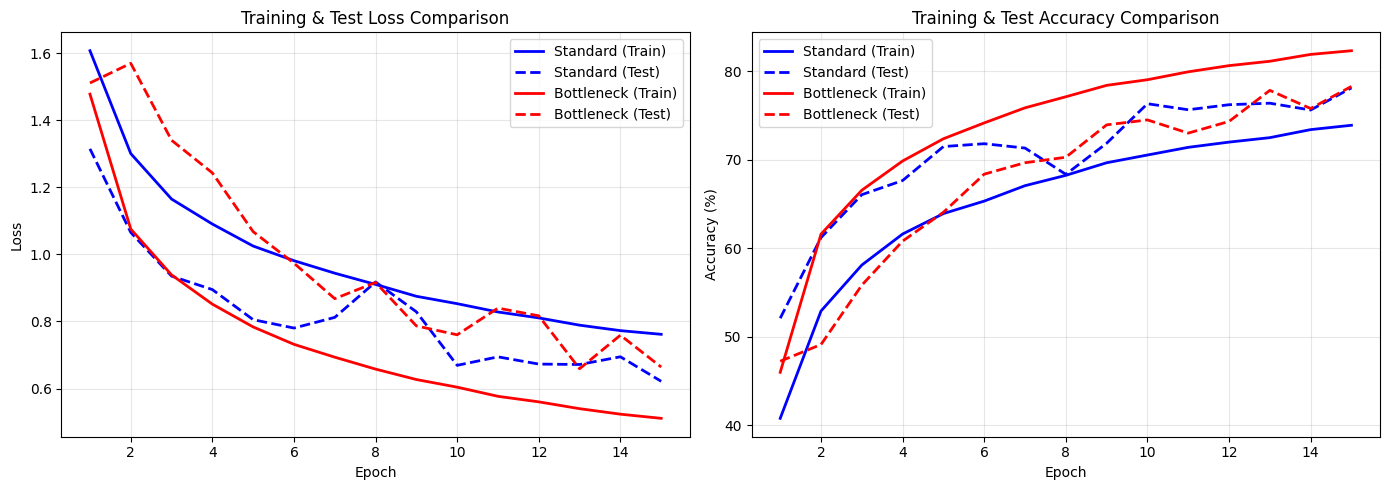

In [23]:
# Plot training curves (provided)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, NUM_EPOCHS + 1)

# Loss comparison
axes[0].plot(epochs, standard_history['train_loss'], 'b-', label='Standard (Train)', linewidth=2)
axes[0].plot(epochs, standard_history['test_loss'], 'b--', label='Standard (Test)', linewidth=2)
axes[0].plot(epochs, bottleneck_history['train_loss'], 'r-', label='Bottleneck (Train)', linewidth=2)
axes[0].plot(epochs, bottleneck_history['test_loss'], 'r--', label='Bottleneck (Test)', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Test Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
axes[1].plot(epochs, standard_history['train_acc'], 'b-', label='Standard (Train)', linewidth=2)
axes[1].plot(epochs, standard_history['test_acc'], 'b--', label='Standard (Test)', linewidth=2)
axes[1].plot(epochs, bottleneck_history['train_acc'], 'r-', label='Bottleneck (Train)', linewidth=2)
axes[1].plot(epochs, bottleneck_history['test_acc'], 'r--', label='Bottleneck (Test)', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training & Test Accuracy Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
def get_predictions(model, data_loader, device):
    """
    Get all predictions and labels from a data loader.

    Returns:
        all_preds: numpy array of predictions
        all_labels: numpy array of true labels
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

In [25]:
def plot_confusion_matrix(model, data_loader, device, class_names, title):
    """
    Plot confusion matrix for a model.
    """

    preds, labels = get_predictions(model, data_loader, device)

    cm = confusion_matrix(labels, preds)

    ax = plt.gca()

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax)

    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    print(f"\n{title}")
    print("="*40)
    print(classification_report(labels, preds, target_names=class_names, digits=3))

    return cm




Standard CNN
              precision    recall  f1-score   support

    airplane      0.817     0.796     0.806      1000
  automobile      0.915     0.867     0.890      1000
        bird      0.743     0.640     0.688      1000
         cat      0.637     0.558     0.595      1000
        deer      0.731     0.784     0.757      1000
         dog      0.641     0.745     0.689      1000
        frog      0.763     0.880     0.817      1000
       horse      0.825     0.804     0.814      1000
        ship      0.897     0.868     0.882      1000
       truck      0.861     0.869     0.865      1000

    accuracy                          0.781     10000
   macro avg      0.783     0.781     0.780     10000
weighted avg      0.783     0.781     0.780     10000


Bottleneck CNN
              precision    recall  f1-score   support

    airplane      0.683     0.908     0.780      1000
  automobile      0.918     0.881     0.899      1000
        bird      0.710     0.705     0.707     

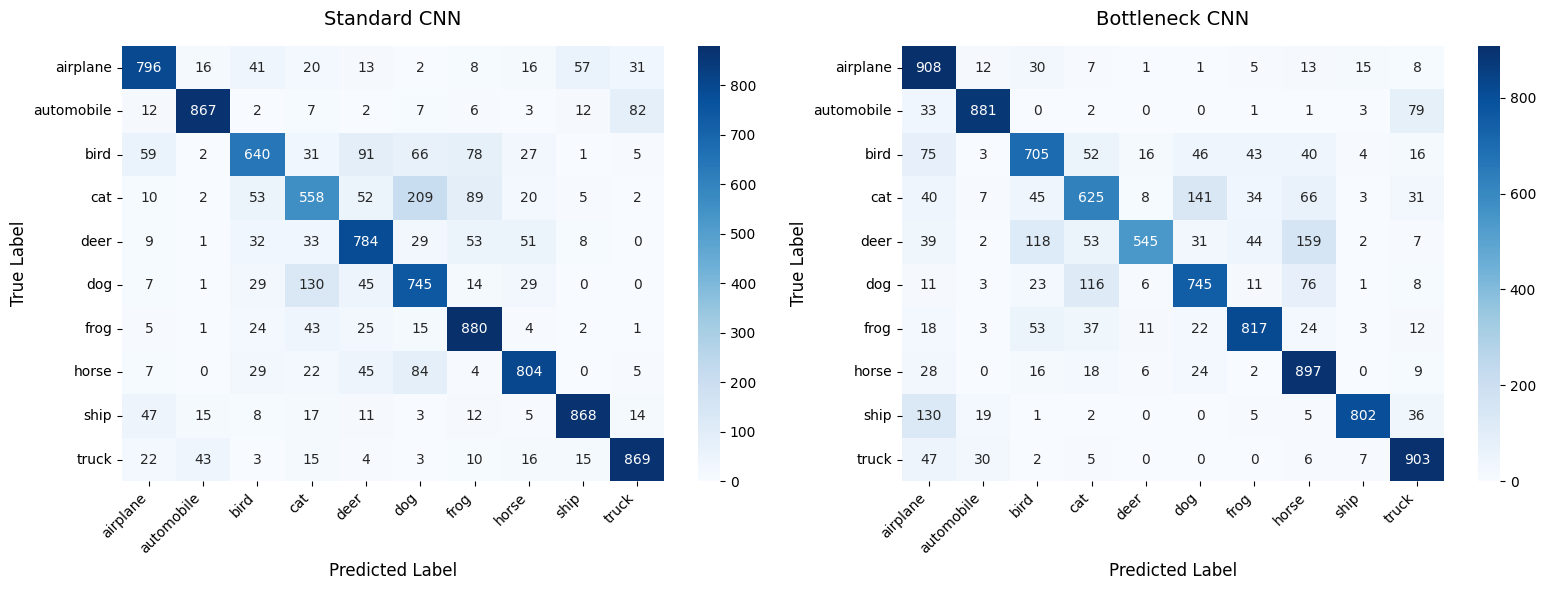

In [26]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.subplot(1, 2, 1)
plot_confusion_matrix(standard_cnn, test_loader, device, CLASS_NAMES, 'Standard CNN')

plt.subplot(1, 2, 2)
plot_confusion_matrix(bottleneck_cnn, test_loader, device, CLASS_NAMES, 'Bottleneck CNN')

plt.tight_layout()
plt.show()

In [27]:
def visualize_predictions(model, dataset, device, class_names, num_samples=10):
    """
    Visualize model predictions on sample images.
    Shows correct predictions in green, incorrect in red.
    """
    model.eval()

    indices = np.random.choice(len(dataset), num_samples, replace=False)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flat

    for i, idx in enumerate(indices):
        # Get image and true label
        image, true_label = dataset[idx]
        true_class = class_names[true_label]

        with torch.no_grad():
            image_tensor = image.unsqueeze(0).to(device)
            output = model(image_tensor)
            _, predicted = torch.max(output, 1)
            predicted_label = predicted.item()
            predicted_class = class_names[predicted_label]


        mean = np.array([0.4914, 0.4822, 0.4465])
        std = np.array([0.2470, 0.2435, 0.2616])

        image_np = image.permute(1, 2, 0).cpu().numpy()
        image_np = image_np * std + mean
        image_np = np.clip(image_np, 0, 1)

        axes[i].imshow(image_np)
        if true_label == predicted_label:
            title_color = 'green'
            title_text = f"True: {true_class}\nPred: {predicted_class}"
        else:
            title_color = 'red'
            title_text = f" X True: {true_class}\nPred: {predicted_class}"

        axes[i].set_title(title_text, color=title_color, fontsize=10)
        axes[i].axis('off')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
    correct = 0
    for idx in indices:
        _, true_label = dataset[idx]
        with torch.no_grad():
            image, _ = dataset[idx]
            image_tensor = image.unsqueeze(0).to(device)
            output = model(image_tensor)
            _, predicted = torch.max(output, 1)
            if true_label == predicted.item():
                correct += 1

    print(f"accuracyon {num_samples}samples: {correct}/{num_samples}({100*correct/num_samples:.1f}%)")

Standard CNN Predictions:


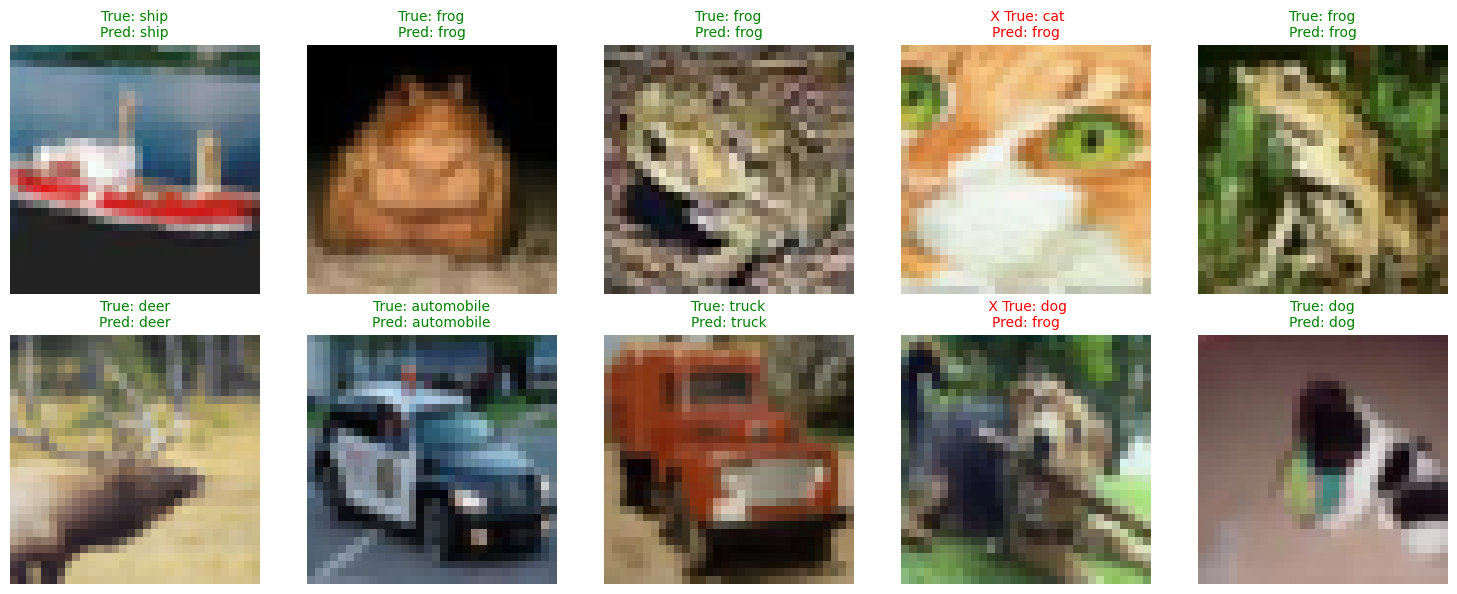

accuracyon 10samples: 8/10(80.0%)

Bottleneck CNN Predictions:


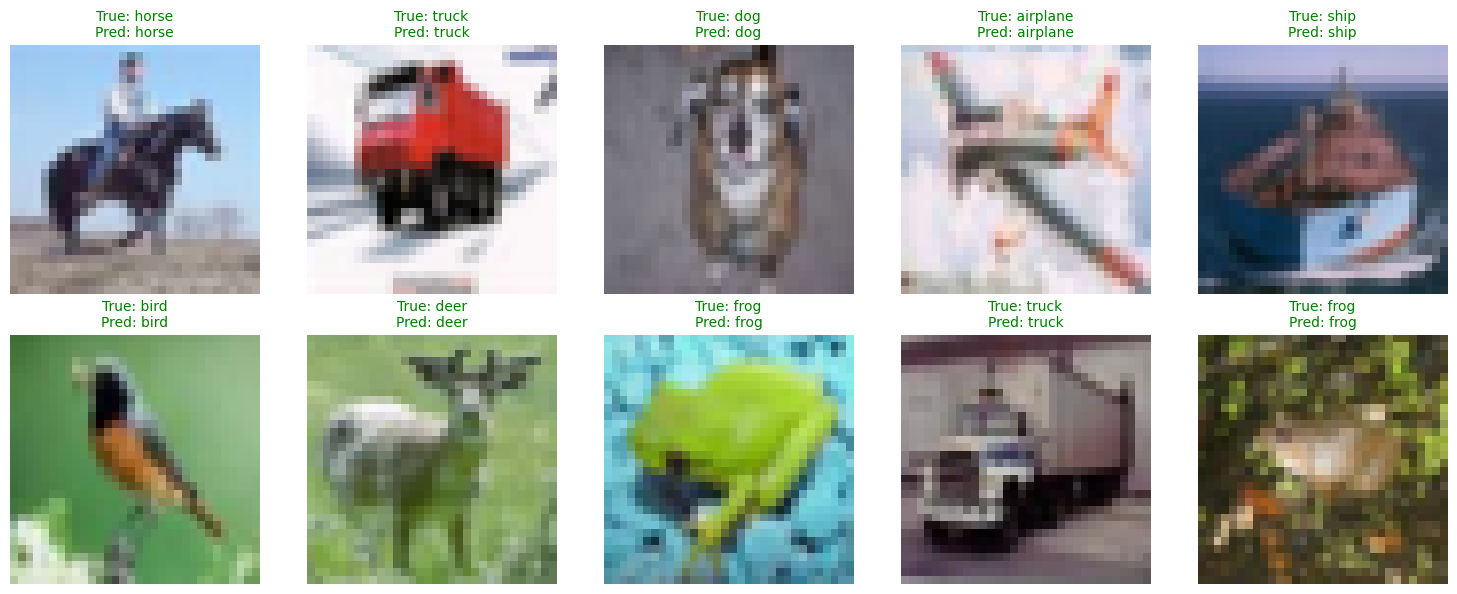

accuracyon 10samples: 10/10(100.0%)


In [28]:
# Visualize predictions for both models
print("Standard CNN Predictions:")
visualize_predictions(standard_cnn, test_dataset, device, CLASS_NAMES)

print("\nBottleneck CNN Predictions:")
visualize_predictions(bottleneck_cnn, test_dataset, device, CLASS_NAMES)

## Part 9: Summary & Analysis 

In [29]:
# Summary statistics (provided)
print("="*60)
print("FINAL COMPARISON SUMMARY")
print("="*60)
print(f"{'Metric':<30} {'Standard CNN':<15} {'Bottleneck CNN':<15}")
print("-"*60)
print(f"{'Parameters':<30} {standard_params:,}" + " "*(15-len(f"{standard_params:,}")) + f"{bottleneck_params:,}")
print(f"{'Final Test Accuracy (%)':<30} {standard_history['test_acc'][-1]:<15.2f} {bottleneck_history['test_acc'][-1]:<15.2f}")
print(f"{'Best Test Accuracy (%)':<30} {max(standard_history['test_acc']):<15.2f} {max(bottleneck_history['test_acc']):<15.2f}")

FINAL COMPARISON SUMMARY
Metric                         Standard CNN    Bottleneck CNN 
------------------------------------------------------------
Parameters                     620,810        122,570
Final Test Accuracy (%)        78.11           78.28          
Best Test Accuracy (%)         78.11           78.28          


### 📝 Analysis Questions

**Question 1:** How do 1×1 convolutions in bottleneck blocks reduce the parameter count? Show a calculation example.

**Question 2:** Compare the accuracy achieved by both models. Is the parameter reduction worth the potential accuracy trade-off?

**Question 3:** Looking at the confusion matrices, which classes are most often confused? Why might this be?

**Your Answers:**

*[Double-click to edit this cell and write your answers here]*

**Answer 1:**
1x1 convolutins reduce the number of parameters by reducing the number of channels before applying larger convolutions like 3x3.Since most parameters come from 3x3 convolutions, lowering the channel count before them saves a lot of parameters.

For example, suppose we have 64 input channels and want 128 output channels
In a stan=dard CNN, a 3x3 convolution directly from 64 to 128 channels would have
3 x 3 x 64 x 128 = 73728 parameters

In a bottleneck block, a 1x1 convolution first reduces channels from 64 to 32
1 x 1 x 64 x 32 = 2048 parameters

Then a 3x3 convolution is applied on the reduced channels
3 x 3 x 32 x 32 = 9216parameters
Finally, another 1x1 convolution expands channels from 32 to 128
1 x 1 x 32 x 128 = 4096 parameters
Total parameters in bottleneck block = 15360
This shows that bottleneck blocks use far fewer parameters than standard convolutions.
Comparison:


**Answer 2:**
The Standard CNN achieved final test accuracy of 78.11percent with 620810 parameters.
The Bottleneck CNN achieved a slightly higherccuracy of 78.28 percent while using only 122570 parameters.
Even thoughthe Bottleneck CNN uses about five timesfewer parameters, its accuracy is slightly better than the Standard CNN. This shows that reducing parameters did not hurt performance.
Therefore, the param][eter reduction is worth it because the Bottleneck CNN is more efficient while maintaining the same or better accuracy.

**Answer 3:**
In both models, the most common confusions ocur between similar looking clases.
Cats and dogs are often confused because they have similar shapes, textures, and body structures.
Deer and horses are also confused because both ar four legged animals and often appear in similar backgrounds.
Birds are sometimes confused with airplanesbecause both have wings and are often shown agait the sky.
Some confusion between ships and truks appears because both have box like shapes in cluttered scenes.
Overall, animal classes are moreconfusing than vehicle classes because their visual differences are smaller at low image resolution. Vehicles have clearer and more rigid shapes, so they are classified more accurately.